In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
df = pd.read_csv("C:\\Users\\Pradeep Kumar\\OneDrive\\Desktop\\HR Attrition proj\\archive (1)\\hr_attrition.csv")
print(f"Dataset shape: {df.shape}")
print(df.head())

Dataset shape: (1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  

In [3]:
# Check missing values
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [4]:
# Drop columns safely - only if they exist
cols_to_drop = ['EmployeeCount', 'Over18', 
                'StandardHours', 'EmployeeNumber']

# This will only drop columns that actually exist
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df = df.drop(columns=cols_to_drop)

print(f"Dropped columns: {cols_to_drop}")
print(f"Remaining columns: {df.shape[1]}")

Dropped columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Remaining columns: 31


In [5]:
# Remove duplicates
df = df.drop_duplicates()
print(f"Clean shape: {df.shape}")  # Should be ~1470 rows, 31 cols

Clean shape: (1470, 31)


Text(0.5, 1.0, 'Overall Attrition')

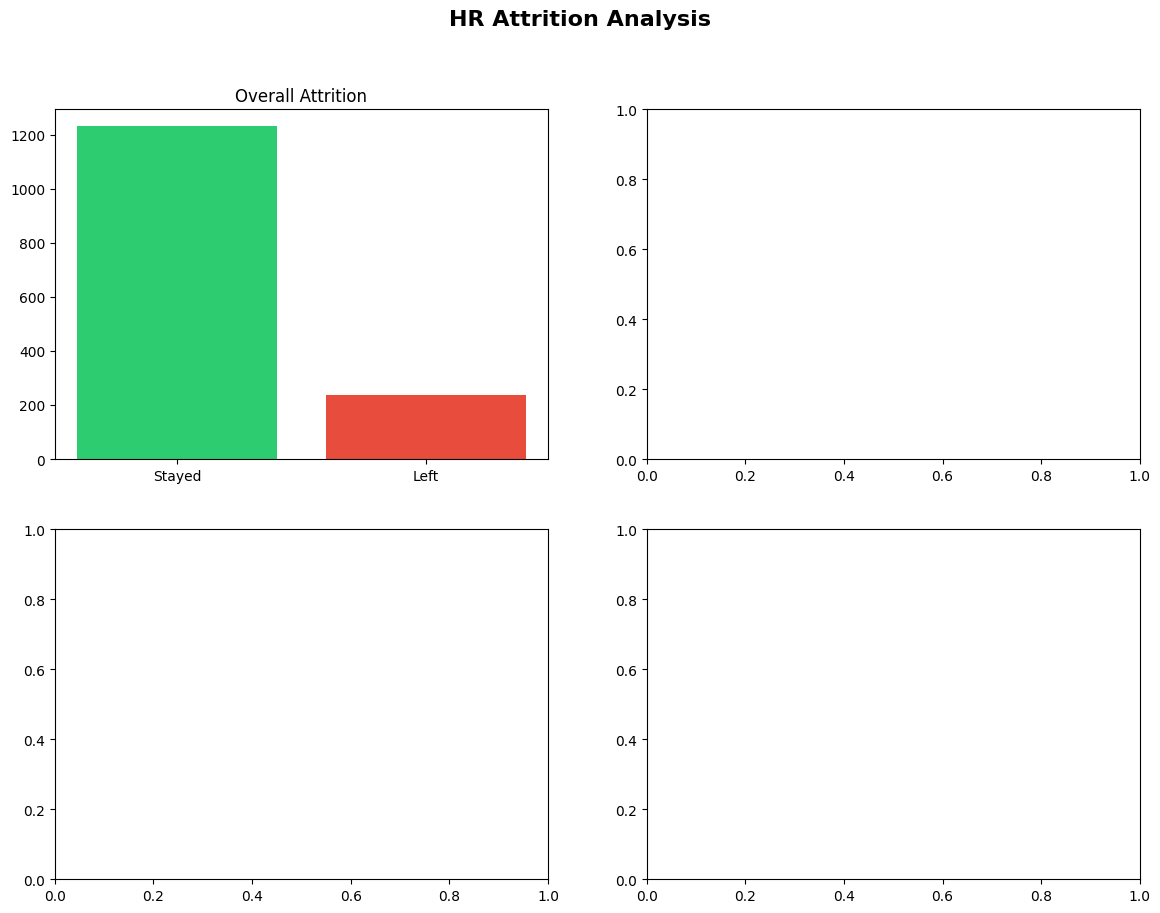

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('HR Attrition Analysis', fontsize=16, fontweight='bold')
# Chart 1: Overall Attrition
counts = df['Attrition'].value_counts()
axes[0,0].bar(['Stayed','Left'], counts.values,
               color=['#2ecc71','#e74c3c'])
axes[0,0].set_title('Overall Attrition')

In [7]:
# Chart 2: By Department
dept = df.groupby('Department')['Attrition'].apply(
    lambda x: (x=='Yes').mean()*100)
axes[0,1].bar(dept.index, dept.values, color=['#3498db','#e67e22','#9b59b6'])
axes[0,1].set_title('Attrition Rate by Department (%)')
# Chart 3: Overtime vs Attrition
ot = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x=='Yes').mean()*100)
axes[1,0].bar(ot.index, ot.values, color=['#27ae60','#c0392b'])
axes[1,0].set_title('Attrition by Overtime (%)')
# Chart 3: Overtime vs Attrition
ot = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x=='Yes').mean()*100)
axes[1,0].bar(ot.index, ot.values, color=['#27ae60','#c0392b'])
axes[1,0].set_title('Attrition by Overtime (%)')

Text(0.5, 1.0, 'Attrition by Overtime (%)')

In [8]:
plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150)
plt.show()
print("Saved: eda_analysis.png")

<Figure size 640x480 with 0 Axes>

Saved: eda_analysis.png


In [9]:
# Make a copy for ML
df_ml = df.copy()
# Convert text columns to numbers (ML needs numbers only)
label_encoders = {}
cat_cols = df_ml.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    label_encoders[col] = le
# X = all features, y = target (Attrition)
X = df_ml.drop('Attrition', axis=1)
y = df_ml['Attrition']
# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training: {X_train.shape[0]} rows")
print(f"Testing:  {X_test.shape[0]} rows")

Training: 1176 rows
Testing:  294 rows


In [10]:
# Train Random Forest
model = RandomForestClassifier(
    n_estimators=100,       # 100 decision trees
    max_depth=10,
    random_state=42,
    class_weight='balanced' # handles imbalanced data
)
model.fit(X_train, y_train)
# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {round(accuracy*100, 2)}%")
print(classification_report(y_test, y_pred,
      target_names=['Stayed','Left']))

Model Accuracy: 83.67%
              precision    recall  f1-score   support

      Stayed       0.85      0.98      0.91       247
        Left       0.45      0.11      0.17        47

    accuracy                           0.84       294
   macro avg       0.65      0.54      0.54       294
weighted avg       0.79      0.84      0.79       294



                 Feature  Importance
15         MonthlyIncome    0.078536
0                    Age    0.074421
23     TotalWorkingYears    0.065148
2              DailyRate    0.052572
26        YearsAtCompany    0.050885
16           MonthlyRate    0.048791
18              OverTime    0.046327
4       DistanceFromHome    0.045193
9             HourlyRate    0.044249
29  YearsWithCurrManager    0.038874


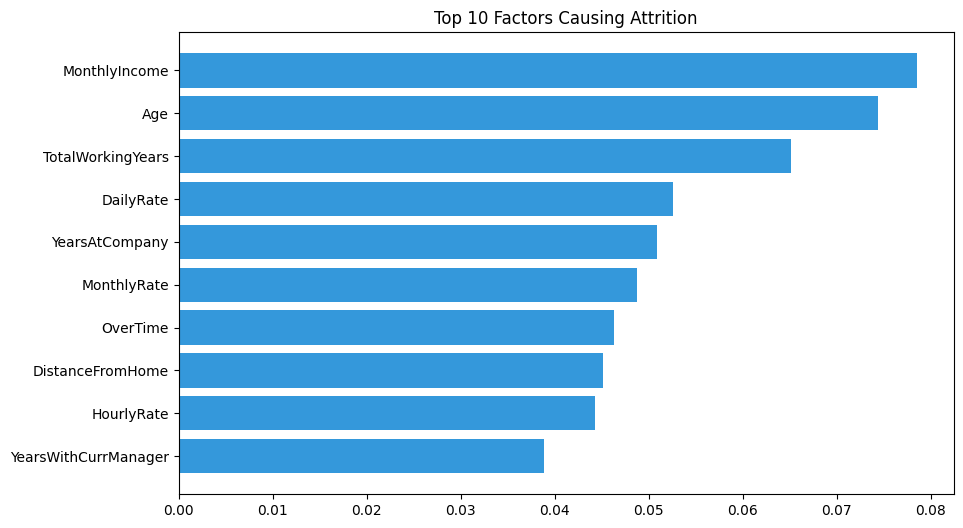

In [11]:
# Top factors causing attrition
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)
print(importance)
# Plot
plt.figure(figsize=(10,6))
plt.barh(importance['Feature'][::-1],
         importance['Importance'][::-1], color='#3498db')
plt.title('Top 10 Factors Causing Attrition')
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [12]:
# Probability of leaving (0 to 1)
risk_scores = model.predict_proba(X)[:, 1]
df['Risk_Score'] = (risk_scores * 100).round(2)
df['Risk_Level'] = pd.cut(df['Risk_Score'],
bins=[0, 30, 60, 100],
labels=['Low Risk', 'Medium Risk', 'High Risk'])
# Show high risk employees still working
high_risk = df[
(df['Attrition'] == 'No') &
(df['Risk_Score'] >= 60)
].sort_values('Risk_Score', ascending=False)
print(f"High Risk Employees: {len(high_risk)}")
print(high_risk[['Department','JobRole','Age',
'Risk_Score','Risk_Level']].head(10))
# Save to CSV
df[df['Attrition']=='No'].sort_values(
'Risk_Score', ascending=False
).to_csv('employee_risk_scores.csv', index=False)
print("Saved: employee_risk_scores.csv")

High Risk Employees: 2
                 Department                JobRole  Age  Risk_Score Risk_Level
301                   Sales   Sales Representative   18       76.40  High Risk
109  Research & Development  Laboratory Technician   22       70.61  High Risk
Saved: employee_risk_scores.csv


In [13]:
import pandas as pd
import requests
import time

GROQ_API_KEY = "Grook_api_key"  # Keep your same key

df = pd.read_csv('employee_risk_scores.csv')
high_risk = df[df['Risk_Level'] == 'High Risk'].head(10).copy()
print(f"Found {len(high_risk)} high risk employees")

def generate_hr_note(emp):
    headers = {
        "Authorization": f"Bearer {GROQ_API_KEY}",
        "Content-Type": "application/json"
    }
    
    payload = {
        "model": "llama-3.3-70b-versatile",
        "messages": [
            {
                "role": "user",
                "content": f"""You are an HR Analytics expert. Write a professional HR note in 3-4 sentences.

Employee Info:
- Department: {emp['Department']}
- Job Role: {emp['JobRole']}
- Age: {emp['Age']}
- Monthly Income: ${emp['MonthlyIncome']}
- Works Overtime: {emp['OverTime']}
- Job Satisfaction: {emp['JobSatisfaction']} out of 4
- Years Since Last Promotion: {emp['YearsSinceLastPromotion']}
- Risk Score: {emp['Risk_Score']}%

State risk level, top 2 reasons they might leave, and ONE HR action."""
            }
        ],
        "max_tokens": 200
    }
    
    for attempt in range(3):
        try:
            response = requests.post(
                "https://api.groq.com/openai/v1/chat/completions",
                headers=headers,
                json=payload
            )
            result = response.json()
            if 'choices' in result:
                return result['choices'][0]['message']['content'].strip()
            else:
                return f"Error: {result}"
        except Exception as e:
            if attempt < 2:
                time.sleep(5)
            else:
                return f"Error: {str(e)}"

ai_notes = []
for idx, (_, emp) in enumerate(high_risk.iterrows()):
    print(f"Processing {idx+1}/{len(high_risk)}...")
    note = generate_hr_note(emp)
    ai_notes.append(note)
    print(f"Note: {note[:100]}...")
    time.sleep(3)

high_risk['AI_HR_Note'] = ai_notes
high_risk.to_csv('high_risk_with_ai_notes.csv', index=False)
print("Done! File saved successfully!")

with open('HR_Risk_Report.txt', 'w') as f:
    f.write("HR ATTRITION RISK REPORT\n" + "="*60 + "\n\n")
    for idx, (_, row) in enumerate(high_risk.iterrows()):
        f.write(f"EMPLOYEE {idx+1}\n" + "-"*40 + "\n")
        f.write(f"Dept: {row['Department']} | Role: {row['JobRole']}\n")
        f.write(f"Risk Score: {row['Risk_Score']}%\n")
        f.write(f"\nAI Note:\n{row['AI_HR_Note']}\n")
        f.write("\n" + "="*60 + "\n\n")
print("Saved: HR_Risk_Report.txt")

Found 2 high risk employees
Processing 1/2...
Note: Based on the data analysis, the Sales Representative's risk score of 76.4% indicates a high risk lev...
Processing 2/2...
Note: Based on the provided data, the Laboratory Technician in the Research & Development department has a...
Done! File saved successfully!
Saved: HR_Risk_Report.txt


In [14]:
import os
print(os.getcwd())

C:\Users\Pradeep Kumar


In [15]:
import pandas as pd
df = pd.read_csv('employee_risk_scores.csv')
print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Risk_Score', 'Risk_Level']


In [21]:
import pandas as pd
import os

# Find the correct path
print(os.getcwd())

# List all CSV files in current folder
for f in os.listdir():
    if f.endswith('.csv'):
        print(f)

C:\Users\Pradeep Kumar
cleaned_data.csv
deliveries_clean.csv
employee_risk_scores.csv
high_risk_with_ai_notes.csv
matches_clean.csv


In [23]:
import pandas as pd

# Load original dataset from correct location
original = pd.read_csv(r'C:\Users\Pradeep Kumar\OneDrive\Desktop\HR Attrition proj\archive (1)\hr_attrition.csv')

# Load risk scores
risk = pd.read_csv('employee_risk_scores.csv')

# Add EmployeeNumber to risk scores
risk['EmployeeNumber'] = original[original['Attrition'] == 'No']['EmployeeNumber'].values

# Save it back
risk.to_csv('employee_risk_scores.csv', index=False)
print("Done! EmployeeNumber added!")
print(risk[['EmployeeNumber', 'Risk_Score', 'Risk_Level']].head())

Done! EmployeeNumber added!
   EmployeeNumber  Risk_Score   Risk_Level
0               2       76.40    High Risk
1               5       70.61    High Risk
2               7       59.69  Medium Risk
3               8       58.74  Medium Risk
4              10       56.18  Medium Risk
